In [1]:
using JuDGE, JuMP, Gurobi, CSV, DataFrames, Chain, Statistics, Plots, DataFramesMeta, StatsPlots, CPLEX

# 1. Data


In [ ]:
enveloppe_area = 40e3    #m2
glazen_area = 4e3       #m2
volume = 96e3
Living_area = 20e3 #m2


air_renewal_day = 0.8*volume  #m3/h 
air_renewal_night = 0.1*volume  #m3/h 
cp_air = 1.2 #kJ/m³·K


u_enveloppe = 2.5 # W/m2

U_enveloppe = u_enveloppe * enveloppe_area /1e3 # kW / K
U_air_day =   air_renewal_day * cp_air   / 3600 # kW / K
U_air_night = air_renewal_night * cp_air / 3600 # kW / K

U_tot_day =   U_enveloppe + U_air_day
U_tot_night = U_enveloppe + U_air_night

internal_gains_day    = 0.020 #kW/m2
internal_gains_night  = 0.003 #kW/m2

I = 2.4e3 #kWh/K

data = CSV.read("data/inputs/preprocessed_days.csv", DataFrame)[:, [:td, :th, :solar_gains, :temperature]]

# Calculate mean temperature for each td group
# td_order = combine(groupby(data, :td), :temperature => mean => :mean_temp)
# sort!(td_order, :mean_temp)
# td_order.new_td = 1:nrow(td_order)

# # Create mapping dictionary
# td_map = Dict(td_order.td[i] => td_order.new_td[i] for i in 1:nrow(td_order))

# # Modify td column in place
# data.td = [td_map[td] for td in data.td]

# Add 1 to td and th columns
transform!(data, :th => ByRow(th -> (8 <= th <= 20) ? 15 : 9) => :T_min)
transform!(data, :th => ByRow(th -> (8 <= th <= 20) ? 25 : 30) => :T_max)
transform!(data, :th => ByRow(th -> (8 <= th <= 20) ? U_tot_day : U_tot_night) => :U_tot)
transform!(data, :th => ByRow(th -> (8 <= th <= 20) ? internal_gains_day * Living_area : internal_gains_night * Living_area) => :Q_internal)

g = groupby(data, :td)

T_heat_supply = combine(g) do sdf
    (; T_heat_supply = maximum(sdf.T_min .+ max.(sdf.T_min .- sdf.temperature, 0)))
end

T_cold_supply = combine(g) do sdf
    (; T_cold_supply = minimum(sdf.T_max .- max.(sdf.temperature .- sdf.T_max, 0)))
end
data = leftjoin(data, T_heat_supply, on=:td)
data = leftjoin(data, T_cold_supply, on=:td)


CO2_tax = CSV.read("data/inputs/CO2_tax_decade.csv", DataFrame)
# CO2_tax[CO2_tax.period .== "2010s","ssp126"]

invest_cost = @chain CSV.read("data/inputs/technology_cost_extrapolations.csv", DataFrame) begin
    filter(:type => (type -> type == "extrapolated"), _)
    transform(:year => ByRow(year -> string(year)[1:3]*"0s") => :year)  # Convert to absolute value
    # filter(:decade => (decade -> !(decade in ["2010s", "2100s"])), _)
end
invest_cost

days =  unique(data[:,:td])
hours = unique(data[:,:th])

# Assuming your dataframe is called 'data'
# Let's create a dictionary for each variable

# Dictionary for solar gains
solar_gains_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    solar_gains_dict[(row.td, row.th)] = row.solar_gains * glazen_area / 1e3
end

# Dictionary for temperature
T_out_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    T_out_dict[(row.td, row.th)] = row.temperature
end


# Dictionary for T_min
T_min_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    T_min_dict[(row.td, row.th)] = row.T_min
end

# Dictionary for T_max
T_max_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    T_max_dict[(row.td, row.th)] = row.T_max
end

# Dictionary for U_tot
U_tot_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    U_tot_dict[(row.td, row.th)] = row.U_tot
end

# Dictionary for U_tot
T_h_supply_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    T_h_supply_dict[(row.td, row.th)] = row.T_heat_supply
end

# Dictionary for U_tot
T_c_supply_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    T_c_supply_dict[(row.td, row.th)] = row.T_cold_supply
end

# Dictionary for U_tot
Q_int_dict = Dict{Tuple{Float64, Float64}, Float64}()
for row in eachrow(data)
    Q_int_dict[(row.td, row.th)] = row.Q_internal
end

In [187]:

Living_area = 35e3 #m2
internal_gains_day    = 0.030 #kW/m2
internal_gains_night  = 0.005 #kW/m2
println(Living_area * internal_gains_night)
println(Living_area * internal_gains_day)

175.0
1050.0


# 2. Tree strucutre
...

In [188]:
df = CSV.read("data/inputs/preprocessed_weights.csv", DataFrame)
# df.td = [td_map[td] for td in df.td]

# Separate the 2020s from other decades
df_2020s = filter(row -> row.decade == "2020s" && row.decade != "2100s", df)
df_other = filter(row -> row.decade != "2020s" && row.decade != "2100s", df)

# For decades other than 2020s: average weight by ssp, decade, and td
result_other = combine(groupby(df_other, [:ssp, :decade, :td]),
    :weight => mean => :weight,
    renamecols=false  # This will keep the original column name as 'weight'
)

# For 2020s: average weight by decade and td only (ignore ssp)
result_2020s = combine(groupby(df_2020s, [:decade, :td]),
    :weight => mean => :weight,
    renamecols=false
)

# Add a placeholder ssp column for 2020s
result_2020s.ssp .= "past"

# Select columns in consistent order and combine
result_other = select(result_other, [:ssp, :decade, :td, :weight])
result_2020s = select(result_2020s, [:ssp, :decade, :td, :weight])

# Final combined result
df_avg = vcat(result_2020s,result_other)

# # Sum weight by ssp and decade
weight_summary = combine(groupby(df_avg, [:ssp, :decade]),
    :weight => sum => :total_weight,
    :weight => length => :count,
    :weight => mean => :mean_weight
)

periods = unique(df_avg[!,"decade"])
paths =   unique(df_avg[!,"ssp"])
states = []
println(periods)
println(paths)

for period in periods
    for ssp in paths
        # Using Chain for more readable pipeline
        result = @chain df_avg begin
            filter(:decade => ==(period), _) 
            filter(:ssp => ==(ssp), _) 
            select(:td, :weight)
        end 
        
        if nrow(result) > 1
            
            invest_dict = Dict{Symbol, Float64}()
            for row in eachrow(filter(x -> x["year"] == period, invest_cost)[:,["technology","cost"]])
                invest_dict[Symbol(row.technology)] = row.cost
            end

            weight_dict = Dict{Int, Float64}()
            for row in eachrow(result)
                weight_dict[Int(row.td)] = row.weight
            end

            # println(invest_dict)
            theState = Dict(
                :period => period,
                :ssp => ssp,
                :weights => weight_dict,
                :CO2_tax => first(CO2_tax[CO2_tax.period .== period,ssp]),
                :invest_cost => invest_dict
            )
            push!(states,theState)
        end
    end
end

String7["2020s", "2030s", "2040s", "2050s", "2060s", "2070s", "2080s", "2090s"]
["past", "ssp126", "ssp245", "ssp370", "ssp585"]


In [189]:
# Create an empty DataFrame with proper column types
df_tree = DataFrame(
    n = Int[], 
    p = Any[],  # Changed from Any[] to String[] since you're only pushing "-"
    depth = Int[],
    degree = Int[] 
)

for (i, state) in enumerate(states)
    if state[:period] in ["2020s"]
        println("start")
        push!(df_tree, (n=i, p="-", degree=length(paths) - 1, depth=0)) 
    else
        depth = findfirst(x -> x == state[:period], periods) - 1  # Using findfirst instead of findall
        period_prev = periods[depth]

        # Fixed the comparison operator (== instead of =) and added proper conditions
        index = findfirst(x -> x[:period] == period_prev && (state[:ssp] == x[:ssp] || depth == 1), states)
        
        if index === nothing
            error("No matching state found for i=$i")
        end
        
        if state[:period] != periods[end]
            push!(df_tree, (n=i, p=index, degree=2, depth=depth))  
        else
            push!(df_tree, (n=i, p=index, degree=1, depth=depth))
        end
    end
end

CSV.write("data/model/Climate_tree.csv",df_tree)

start


"data/model/Climate_tree.csv"

In [190]:
mytree, p = tree_from_file("data/model/Climate_tree.csv")

data                = Dict( zip( collect(mytree,order=:breadth), states) )
period_tree         = Dict( zip(collect(mytree,order=:breadth), [d[:period] for d in states]))
ssp_tree            = Dict( zip(collect(mytree,order=:breadth), [d[:ssp] for d in states]))
day_weight_tree     = Dict( zip(collect(mytree,order=:breadth), [d[:weights] for d in states]))
CO2_tax_tree        = Dict( zip(collect(mytree,order=:breadth), [d[:CO2_tax] for d in states]))
invest_tree         = Dict( zip(collect(mytree,order=:breadth), [d[:invest_cost] for d in states]))
# invest_tree
# JuDGE.print_tree(mytree,invest_tree)
# JuDGE.print_tree(mytree,period_tree)
# JuDGE.print_tree(mytree,CO2_tax_tree)


Dict{AbstractTree, Dict{Symbol, Float64}} with 29 entries:
  Subtree rooted at node 6… => Dict(:NG_boiler=>131.0, :ASHP=>1025.05, :E_boile…
  Subtree rooted at node 1… => Dict(:NG_boiler=>131.0, :ASHP=>964.143, :E_boile…
  Subtree rooted at node 2… => Dict(:NG_boiler=>131.0, :ASHP=>927.197, :E_boile…
  Subtree rooted at node 1… => Dict(:NG_boiler=>131.0, :ASHP=>943.655, :E_boile…
  Subtree rooted at node 2… => Dict(:NG_boiler=>131.0, :ASHP=>927.197, :E_boile…
  Subtree rooted at node 5… => Dict(:NG_boiler=>131.0, :ASHP=>1073.19, :E_boile…
  Subtree rooted at node 2… => Dict(:NG_boiler=>131.0, :ASHP=>1073.19, :E_boile…
  Subtree rooted at node 1… => Dict(:NG_boiler=>131.0, :ASHP=>964.143, :E_boile…
  Subtree rooted at node 1… => Dict(:NG_boiler=>131.0, :ASHP=>990.349, :E_boile…
  Subtree rooted at node 2… => Dict(:NG_boiler=>131.0, :ASHP=>927.197, :E_boile…
  Leaf node 28              => Dict(:NG_boiler=>131.0, :ASHP=>913.687, :E_boile…
  Subtree rooted at node 2… => Dict(:NG_boiler=>13

In [191]:
H_assets = [:GSHP, :NG_boiler, :ASHP, :E_boiler]
C_assets = [:ASHP,:GSHP]


Assets_colors = Dict(
    :GSHP => RGB(0.98, 0.4, 0.02), 
    :ASHP => RGB(0.01,0.2,0.6), 
    :NG_boiler => RGB(0.4, 0.4, 0.4),
    :E_boiler  => RGB(0.01,0.2,0.0)
)

# Investment Costs (€/MW)
c_investment_cost_H = Dict(
    :GSHP => 0.3e6,
    :ASHP => 0.5e6,
    :NG_boiler => 0.1e6,
    :E_boiler  => 0.1e6
)

price_drilling = 0.8e6 #€/MW of heat

# Maximum Additional Capacity (MW)
c_max_additional_capacity = Dict(
    :NG_boiler => 1e6,
    :ASHP => 1e6,
    :GSHP => 1e6,
    :E_boiler  => 1e6
)
max_add_btes = 1e6

# Initial Capacities (MW)
c_initial_capacity = Dict(
    :NG_boiler => 0,
    :ASHP => 600,
    :GSHP => 0,
    :E_boiler  => 0
)
initial_btes = 0

prim = Dict(
    :NG_boiler => :Gas,
    :ASHP => :Elec,
    :GSHP => :Elec,
    :E_boiler  => :Elec
)

# in ton €/MWh
primary_cost = Dict(
    :Elec => 300,
    :Gas => 50
)

# in ton CO2/MWh
primary_emission = Dict(
    :Elec => 0.15,
    :Gas => 0.2
)

# in ton €/MWh
c_unmet = 1e6

function HP_COP_H(T_sink, T_source)
    return 0.6*(273.15 + T_sink)/((T_sink - T_source)+10)
end

function HP_COP_C(T_sink, T_source)
    COP = 0.6*(273.15 + T_sink)/((T_sink - T_source)+10)
    return COP - 1
end

function Geo_COP_H(T_sink, T_source)
    return 0.6*(273.15 + T_sink)/((T_sink - 10)+10)
end

function Geo_COP_C(T_sink, T_source)
    COP = 20
    return COP - 1
end


function efficient_Boiler(a,b)
    return 0.9
end


# Efficiency (as a fraction)
efficiency_H = Dict(
    :NG_boiler => efficient_Boiler,
    :ASHP => HP_COP_H,
    :GSHP => Geo_COP_H,
    :E_boiler  => efficient_Boiler
)


# Efficiency (as a fraction)
efficiency_C = Dict(
    :ASHP => HP_COP_C,
    :GSHP => Geo_COP_C
)
        

Dict{Symbol, Function} with 2 entries:
  :ASHP => HP_COP_C
  :GSHP => Geo_COP_C

# 1. Model

- Il faut ajouter le bon coefficient pour les jours

- Il faut ajouter les bons prix pour les technologies

- Il faut rajouter les temperature de fourniture de chaud et de froid

- Il faut rajouter les pertes thermiques dans les tuyaux

In [213]:
JuDGE_SP_Solver = optimizer_with_attributes(CPLEX.Optimizer,"CPX_PARAM_SCRIND" => 0, "CPX_PARAM_EPGAP" => 0.01)#, "OutputFlag" => 0, "MIPGap" => 0.0)
function sub_problems(node)
    sp = Model(JuDGE_SP_Solver)

    # Heat and cold produced and unmet for every assets
    @variable(sp, T[days,hours])
    @variable(sp, 0 <= T_min_unmet[days,hours])
    @variable(sp, 0 <= T_max_unmet[days,hours])

    @variable(sp, 0 <= H_heat_prod[ H_assets,days,hours])
    @variable(sp, 0 <= C_heat_prod[ C_assets,days,hours])
    @variable(sp, 0 <= H_btes[days,hours]) # Heat and cold extracted from BTES
    @variable(sp, 0 <= C_btes[days,hours]) # Heat and cold extracted from BTES
    
    # Expansion variables (technologies and BTES)
    duration_tech = 2
    duration_btes = 5
    @expansion(sp, 0 <= BTES <= 2000, lag = 1, duration = duration_btes)
    @expansion(sp, 0 <= invest[H_assets] <= 1e6, lag = 1, duration = duration_tech)
    @constraint(sp, MaxInvest[tech in H_assets], invest[tech] <= c_max_additional_capacity[tech])

    # Indoor temperature evolution
    evol =     @constraint(sp, T_evolution[d in days, h in hours], I*(T[d,(h+1)%length(hours)] - T[d,h]) == U_tot_dict[d,h] * (T_out_dict[d,h]-T[d,h]) + solar_gains_dict[d,h] / 2 + Q_int_dict[d,h] + sum(H_heat_prod[tech,d,h] for tech in H_assets) - sum(C_heat_prod[tech,d,h] for tech in C_assets))
    # println("evol constraints")
    # println(evol)
    # Constraint T : defining distance to comfort zone
    @constraint(sp, low_T[d in days, h in hours], T_min_dict[d,h] <= T[d,h] + T_min_unmet[d,h])
    @constraint(sp, up_T[d in days, h in hours], T_max_dict[d,h] >= T[d,h] - T_max_unmet[d,h])
    
    # # Relation heat and cold for btes and system output
    @constraint(sp, H_btes_def[d in days, h in hours], H_btes[d,h] == H_heat_prod[:GSHP,d,h] * (efficiency_H[:GSHP](T_h_supply_dict[d,h], 10.0) - 1)/efficiency_H[:GSHP](T_h_supply_dict[d,h], T_out_dict[d,h]))
    @constraint(sp, C_btes_def[d in days, h in hours], C_btes[d,h] == C_heat_prod[:GSHP,d,h] * (efficiency_C[:GSHP](10.0, T_c_supply_dict[d,h]) + 1)/efficiency_C[:GSHP](T_out_dict[d,h], T_c_supply_dict[d,h]))

    # # Objective function per assets and bte
    coeff_btes = min(duration_btes, 7 - JuDGE.depth(node))/duration_btes
    coeff_tech = min(duration_tech, 7 - JuDGE.depth(node))/duration_tech
    @capitalcosts(sp, coeff_btes * invest_tree[node][:BTES] * BTES + coeff_tech * sum(invest_tree[node][h] * invest[h] for h in H_assets))

    if ssp_tree[node] == "past"
        @constraint(sp, H_max_capa[tech in H_assets, d in days, h in hours], H_heat_prod[tech,d,h]/efficiency_H[tech](T_h_supply_dict[d,h], T_out_dict[d,h]) <= c_initial_capacity[tech])
        @constraint(sp, C_max_capa[tech in C_assets, d in days, h in hours], C_heat_prod[tech,d,h]/efficiency_C[tech](T_out_dict[d,h], T_c_supply_dict[d,h]) <= c_initial_capacity[tech])
        @constraint(sp, H_max_btes[d in days, h in hours], H_btes[d,h] <= initial_btes)
        @constraint(sp, C_max_btes[d in days, h in hours], C_btes[d,h] <= initial_btes)
    else
        @constraint(sp, H_max_capa[tech in H_assets, d in days, h in hours], H_heat_prod[tech,d,h]/efficiency_H[tech](T_h_supply_dict[d,h], T_out_dict[d,h]) <= invest[tech])
        @constraint(sp, C_max_capa[tech in C_assets, d in days, h in hours], C_heat_prod[tech,d,h]/efficiency_C[tech](T_out_dict[d,h], T_c_supply_dict[d,h]) <= invest[tech])
        @constraint(sp, H_max_btes[d in days, h in hours], H_btes[d,h] <= BTES)
        @constraint(sp, C_max_btes[d in days, h in hours], C_btes[d,h] <= BTES)
    end
    
    @constraint(sp, Geo_balancing, sum(H_btes[d,h] - C_btes[d,h] for d in days for h in hours) == 0)

    # # Create expressions for each subpart
    heat_cost = @expression(sp, sum(day_weight_tree[node][d] * H_heat_prod[tech,d,h]/efficiency_H[tech](T_h_supply_dict[d,h], T_out_dict[d,h]) * (primary_cost[prim[tech]] + primary_emission[prim[tech]] * CO2_tax_tree[node]) for tech in H_assets, d in days, h in hours))
    cool_cost = @expression(sp, sum(day_weight_tree[node][d] *  C_heat_prod[tech,d,h]/efficiency_C[tech](T_out_dict[d,h], T_c_supply_dict[d,h]) * (primary_cost[prim[tech]] + primary_emission[prim[tech]] * CO2_tax_tree[node]) for tech in C_assets, d in days, h in hours))
    unmet_cost = @expression(sp, sum(day_weight_tree[node][d] * (T_min_unmet[d,h]+T_max_unmet[d,h]) for d in days for h in hours))
    
    a = @objective(sp, Min, 10e4*unmet_cost + heat_cost + cool_cost)
    
    return sp
end

sub_problems (generic function with 1 method)

In [214]:
# First make sure you have Gurobi installed and added to your Julia environment
# using Pkg; Pkg.add("Gurobi")
# Replace GLPK with Gurobi optimizer
JuDGE_MP_Solver = optimizer_with_attributes(CPLEX.Optimizer,"CPX_PARAM_SCRIND" => 0, "CPX_PARAM_EPGAP" => 0.01) 
    # Gurobi parameter for suppressing output
#                           )   # Gurobi parameter for MIP gap tolerance

judy = JuDGEModel(mytree, ConditionallyUniformProbabilities, sub_problems, JuDGE_MP_Solver)


1

[ Info: Establishing JuDGE model for tree: Subtree rooted at node 1 containing 29 nodes
[ Info: Building JuMP Model for node 


261014182226371115192327481216202428591317212529s...Complete


[ Info: Checking sub-problem format...


Complete
Complete


[ Info: Building master problem...


JuDGE Model with:
  Tree: Subtree rooted at node 1 containing 29 nodes
  Expansion variables: BTES invest 

In [215]:
JuDGE.solve(judy,termination=Termination(rlx_abstol=10^-8),verbose=1)
JuDGE.print_expansions(judy)


Relaxed ObjVal  |   Upper Bound   Lower Bound  |  Absolute Diff   Relative Diff  |  Fractional  |      Time     Iter


[ Info: Solving JuDGE model for tree: Subtree rooted at node 1 containing 29 nodes


           Inf  |           Inf          -Inf  |            Inf             NaN  |           0  |     3.815        1
  2.429489e+10  |  2.429489e+10          -Inf  |            Inf             NaN  |           0  |     5.332        2
  2.315138e+10  |  2.315138e+10  1.532412e+10  |   7.827264e+09    5.107807e-01  |           0  |     7.116        3
  1.892006e+10  |  1.892006e+10  1.637164e+10  |   2.548420e+09    1.556606e-01  |           0  |     7.190        4
  1.833908e+10  |  1.833908e+10  1.640302e+10  |   1.936058e+09    1.180306e-01  |           0  |     7.270        5
  1.701518e+10  |  1.701518e+10  1.640313e+10  |   6.120496e+08    3.731298e-02  |           0  |     7.338        6
  1.640934e+10  |  1.640934e+10  1.640320e+10  |   6.141085e+06    3.743833e-04  |           0  |     7.426        7
  1.640584e+10  |  1.640584e+10  1.640375e+10  |   2.092714e+06    1.275753e-04  |           0  |     7.503        8
  1.640508e+10  |  1.640508e+10  1.640414e+10  |   9.436414e+05 

In [216]:
using DataFrames
using Plots
using Statistics

function dict_to_dataframe(node_dict::Dict{String, Float64})
    """
    Convert dictionary with keys "day,hour" to DataFrame with columns:
    day, hour, temperature
    """
    # Initialize vectors
    days = Int[]
    hours = Int[]
    temperatures = Float64[]
    
    # Parse each key-value pair
    for (key_str, temp) in node_dict
        # Split the key string
        day_str, hour_str = split(key_str, ",")
        
        # Parse to integers and add to vectors
        push!(days, parse(Int, day_str))
        push!(hours, parse(Int, hour_str))
        push!(temperatures, temp)
    end
    
    # Create DataFrame
    df = DataFrame(
        day = days,
        hour = hours,
        temperature = temperatures
    )
    
    # Sort by day and hour for easier analysis
    sort!(df, [:day, :hour])
    
    return df
end


function dict_to_dataframe2(node_dict::Dict{Tuple{Float64, Float64}, Float64})
    """
    Convert dictionary with keys "day,hour" to DataFrame with columns:
    day, hour, temperature
    """
    # Initialize vectors
    days = Int[]
    hours = Int[]
    temperatures = Float64[]
    
    # Parse each key-value pair
    for (key_str, temp) in node_dict
        # Split the key string
        day_str, hour_str = key_str[1], key_str[2]
        
        # Parse to integers and add to vectors
        push!(days, day_str)
        push!(hours, hour_str)
        push!(temperatures, temp)
    end
    
    # Create DataFrame
    df = DataFrame(
        day = days,
        hour = hours,
        temperature = temperatures
    )
    
    # Sort by day and hour for easier analysis
    sort!(df, [:day, :hour])
    
    return df
end

function plot_temperature_by_day(p, df::DataFrame, node_name="", color = "black")
    """
    Create subplots for each day showing temperature vs hour.
    
    Args:
        df: DataFrame with columns day, hour, temperature
        node_name: Optional name for the plot title
    """
    # Create a color palette for different days
    colors = palette(:tab20)
    
    # Plot each day in its own subplot
    for (idx, day) in enumerate(unique_days)
        # Filter data for this day
        day_df = df[df.day .== day, :]
        
        # Sort by hour
        sort!(day_df, :hour)
        
        # Switch to current subplot
        plot!(p[idx],
            day_df.hour, day_df.temperature;
            label=node_name,
            xlabel="Hour",
            # ylabel="Temperature (°C)",
            title="Day $day",
            linewidth=2,
            markersize=6,
            color=color,
            grid=true,
            framestyle=:box,
            legend=:topleft)

    end
    
    return p
end

function plot_tolerance(p, df::DataFrame, node_name="")
    """
    Create subplots for each day showing temperature vs hour.
    
    Args:
        df: DataFrame with columns day, hour, temperature
        node_name: Optional name for the plot title
    """
    # Create a color palette for different days
    colors = palette(:tab20)
    
    # Plot each day in its own subplot
    for (idx, day) in enumerate(unique_days)
        # Filter data for this day
        day_df = df[df.day .== day, :]
        # Create lower and upper vectors based on hour condition
        lower = [if 8 <= h <= 20 15 else 9 end for h in day_df.hour]
        upper = [if 8 <= h <= 20 25 else 30 end for h in day_df.hour]


        # Fill the area between lower and upper bounds
        # Plot the filled area first (as background)
        plot!(p[idx],
            day_df.hour, lower;
            fillrange=upper,
            fillalpha=0.3,
            fillcolor=:green,
            label="Comfort Zone",
            linealpha=0,
            linewidth=0,
            xlabel="Hour",
            # ylabel="Temperature (°C)",
            title="Day $day",
            grid=true,
            framestyle=:box,
            legend=:topleft)
    end
    
    return p
end



plot_tolerance (generic function with 2 methods)

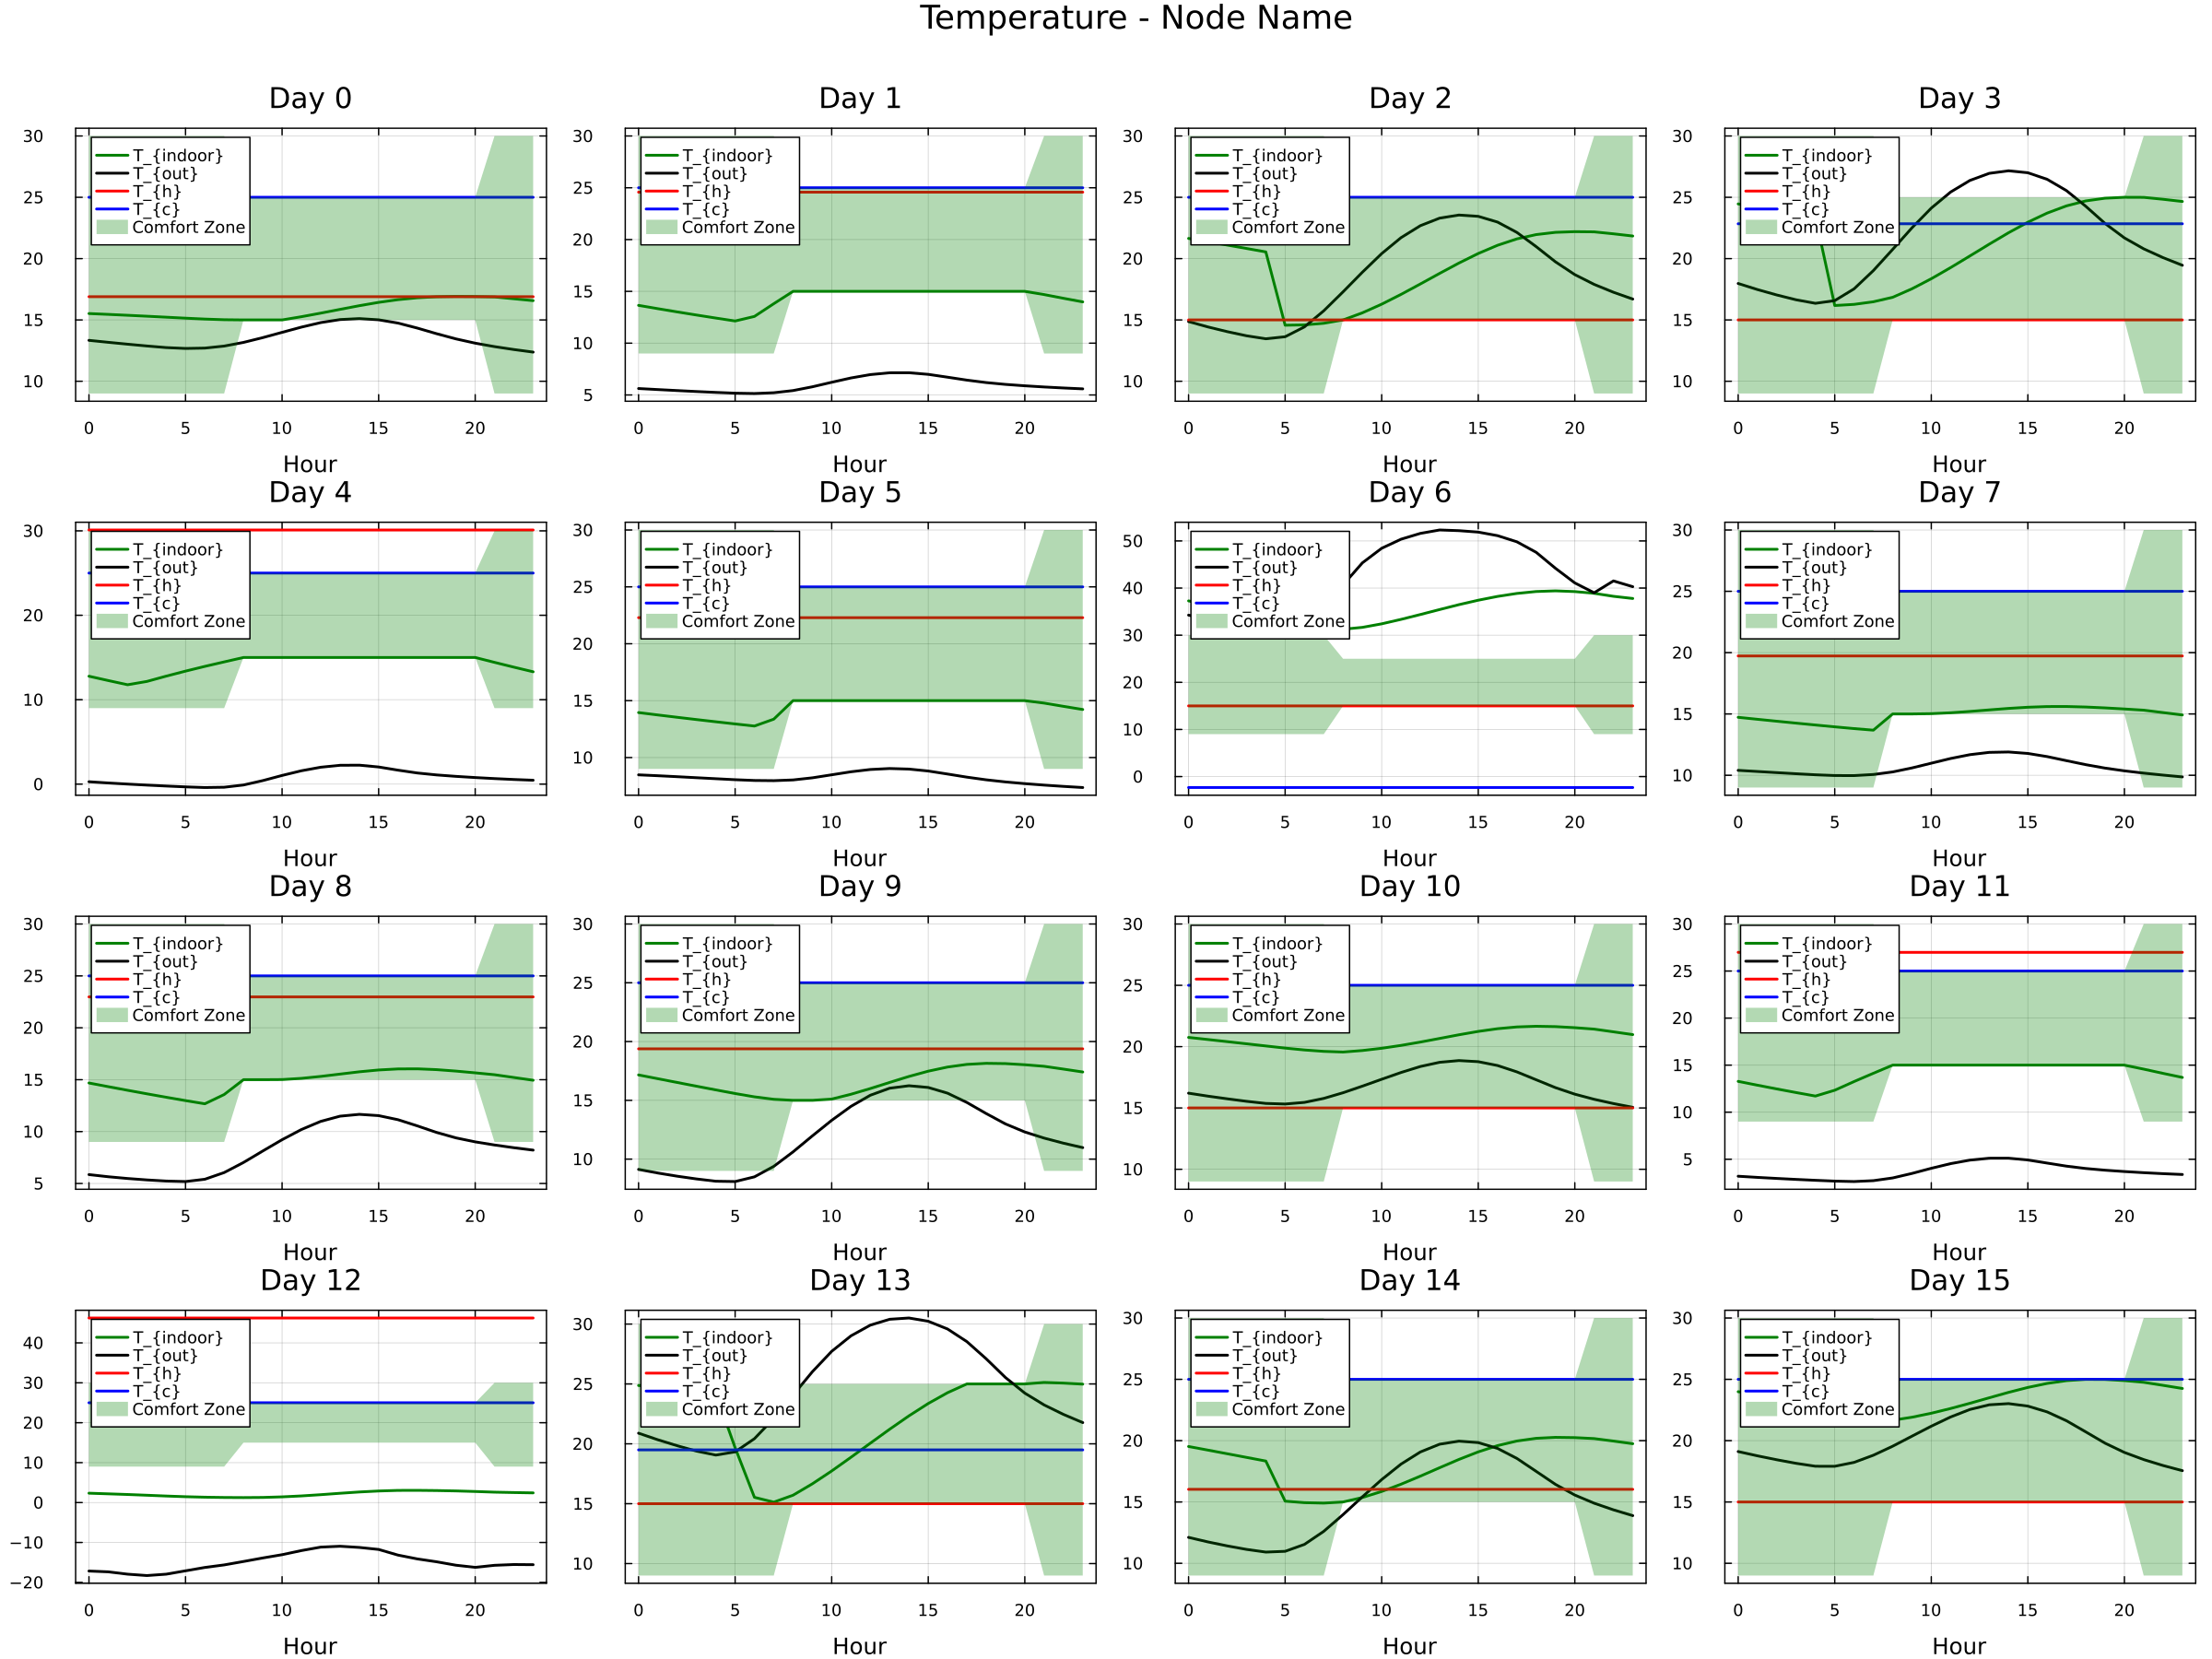

In [217]:
solution = JuDGE.solution_to_dictionary(judy)
node = JuDGE.get_node(mytree,[1])

# For your actual data
# df, stats, subplot_fig, combined_fig = analyze_and_plot_temperature(solution[node][:T], "Node Name")

# Or just the conversion
df = dict_to_dataframe(solution[node][:T])
df2 = dict_to_dataframe2(T_out_dict)
df3 = dict_to_dataframe2(T_h_supply_dict)
df4 = dict_to_dataframe2(T_c_supply_dict)


# Get unique days
node_name = "Node Name"
unique_days = sort(unique(df.day))
n_days = length(unique_days)

# Calculate subplot layout
n_cols = min(4, n_days)  # Maximum 3 columns
n_rows = ceil(Int, n_days / n_cols)

# Create main plot with subplots
plot_title = isempty(node_name) ? "Temperature by Day" : "Temperature - $node_name"

p = plot(layout=(n_rows, n_cols),
            size=(400 * n_cols, 300 * n_rows),
            plot_title=plot_title,
            dpi=150)

# Then plot
subplot_fig = plot_temperature_by_day(p, df, "T_{indoor}", "green")
subplot_fig = plot_temperature_by_day(p, df2, "T_{out}", "black")
subplot_fig = plot_temperature_by_day(p, df3, "T_{h}", "red")
subplot_fig = plot_temperature_by_day(p, df4, "T_{c}", "blue")
subplot_fig = plot_tolerance(p, df2, "T_{out}")

# savefig(p,"output/operations/temperatures.pdf")

# 4. Output
Il faut extraire des tables

Losses
SSP | Decade | Day | Hour | Loss type | value

Energy
SSP | Decade | Day | Hour | Technology | Output | Efficiency | Input | Input_cost | CO2 | CO2_cost

Comfort
SSP | Decade | Day | Hour | Delta_T | Delta_T_cost

Investment
SSP | Decade | Technology | Expansion | Alive | Retirement | Expansion (cost)

Comme figures, il faudrait:

- Evolution de l'OPEX par scenario (avec incertitudes inter-modeles)

- Evolution des capacites thermiques

- Evolution de la demande par categorie et variation inter-modele
    
    - gains thermiques (totales)
    - pertes thermiques (totales)

- Simulation du borehole

In [218]:

function get_all_node_positions()
    res = Vector()
    for period in 1:length(periods)
        for ssp in 1:length(paths)-1
            if period == 1
                node_position = [1]
                push!(res,node_position)
            # elseif paths[ssp] == "past"
                
            elseif period == 2
                node_position = [1,ssp]
                push!(res,node_position)
            else
                node_position = vcat([1,ssp],repeat([1], outer = [period - 2]))
                push!(res,node_position)
            end
            if period == 1
                break
            end
        end
    end
    return res
end

for (i, pos) in enumerate(get_all_node_positions())

    node = JuDGE.get_node(mytree, pos)
    short_sol = solution[node]      
    show(short_sol)
    for (t,d,h) in zip(H_assets,days,hours)
        println(t,d,h)
        println([short_sol[:H_heat_prod]["$(t),$(d),$(h)"]])
        break
    end
    break
end

Dict{Symbol, Any}(:H_heat_prod => Dict("GSHP,11,4" => 0.0, "GSHP,11,8" => 0.0, "GSHP,12,4" => 0.0, "ASHP,11,20" => 0.0, "GSHP,2,12" => 0.0, "GSHP,13,6" => 0.0, "ASHP,14,6" => 0.0, "GSHP,15,9" => 0.0, "E_boiler,10,11" => 0.0, "NG_boiler,1,18" => 0.0, "ASHP,9,23" => 0.0, "ASHP,11,13" => 544.5133883312446, "E_boiler,15,2" => 0.0, "E_boiler,12,9" => 0.0, "E_boiler,12,15" => 0.0, "ASHP,4,0" => 0.0, "ASHP,15,22" => 0.0, "E_boiler,8,5" => 0.0, "NG_boiler,9,23" => 0.0, "ASHP,8,7" => 3959.509405228477, "ASHP,8,2" => 0.0, "ASHP,0,20" => 0.0, "ASHP,3,6" => 0.0, "E_boiler,14,11" => 0.0, "GSHP,10,9" => 0.0, "ASHP,3,3" => 0.0, "NG_boiler,10,2" => 0.0, "ASHP,0,6" => 0.0, "GSHP,13,10" => 0.0, "ASHP,14,0" => 0.0, "NG_boiler,15,5" => 0.0, "E_boiler,11,3" => 0.0, "ASHP,14,10" => 0.0, "NG_boiler,6,12" => 0.0, "ASHP,11,23" => 0.0, "NG_boiler,8,0" => 0.0, "ASHP,3,13" => 0.0, "NG_boiler,8,15" => 0.0, "ASHP,7,18" => 0.0, "GSHP,4,6" => 0.0, "GSHP,4,14" => 0.0, "E_boiler,15,21" => 0.0, "NG_boiler,4,9" => 0.0, "

In [219]:

# Details losses export
loss_records = []
for (i, pos) in enumerate(get_all_node_positions())
    node = JuDGE.get_node(mytree, pos)
    short_sol = solution[node]
    this_period = period_tree[node]
    this_ssp = ssp_tree[node]
    
    for d in days, h in hours
        T_inside = short_sol[:T]["$(d),$(h)"]
        
        # Wall losses (envelope)
        push!(loss_records, (this_ssp, this_period, d, h, "Wall",
                            U_enveloppe * (T_out_dict[d,h] - T_inside)))
        
        # Ventilation losses with time-dependent U_air
        U_air = if 8 <= T_inside <= 20
            U_air_day
        else
            U_air_night
        end
        push!(loss_records, (this_ssp, this_period, d, h, "Ventilation",
                            U_air * (T_out_dict[d,h] - T_inside)))
        
        # Gains (negative losses)
        push!(loss_records, (this_ssp, this_period, d, h, "Solar", solar_gains_dict[d,h]/2))
        
        push!(loss_records, (this_ssp, this_period, d, h, "Internal", Q_int_dict[d,h]))
    end
end

losses_df = DataFrame(loss_records, [:SSP, :Decade, :Day, :Hour, :Loss_type, :Value])
CSV.write("output/operations/TD_losses.csv", losses_df)


# Details production export
prod_records = []
for (i, pos) in enumerate(get_all_node_positions())
    node = JuDGE.get_node(mytree, pos)
    short_sol = solution[node]
    this_period = period_tree[node]
    this_ssp = ssp_tree[node]
    
    for d in days, h in hours, t in H_assets
        H_heat_prod = short_sol[:H_heat_prod]["$(t),$(d),$(h)"]
        if t in C_assets
            C_heat_prod = short_sol[:C_heat_prod]["$(t),$(d),$(h)"]
        else 
            C_heat_prod = 0
        end
        
        push!(prod_records, (this_ssp, this_period, t, d, h, H_heat_prod - C_heat_prod))
    end
end

prod_df = DataFrame(prod_records, [:SSP, :Decade, :Technology, :Day, :Hour, :Value])
CSV.write("output/operations/production_details.csv", prod_df)
show(prod_df)


44544×6 DataFrame
   Row │ SSP     Decade   Technology  Day    Hour   Value   
       │ String  String7  Symbol      Int64  Int64  Float64 
───────┼────────────────────────────────────────────────────
     1 │ past    2020s    GSHP            0      0      0.0
     2 │ past    2020s    NG_boiler       0      0      0.0
     3 │ past    2020s    ASHP            0      0      0.0
     4 │ past    2020s    E_boiler        0      0      0.0
     5 │ past    2020s    GSHP            0      1      0.0
     6 │ past    2020s    NG_boiler       0      1      0.0
     7 │ past    2020s    ASHP            0      1      0.0
     8 │ past    2020s    E_boiler        0      1      0.0
     9 │ past    2020s    GSHP            0      2      0.0
    10 │ past    2020s    NG_boiler       0      2      0.0
    11 │ past    2020s    ASHP            0      2      0.0
   ⋮   │   ⋮        ⋮         ⋮         ⋮      ⋮       ⋮
 44535 │ ssp585  2090s    ASHP           15     21      0.0
 44536 │ ssp585  2090s